In [31]:
import tools

In [32]:
import time

In [33]:
tools.ext.np.set_printoptions(precision=8, suppress=True, floatmode="fixed")

In [34]:
pn1 = "../sub-01/ses-1/noRAS"
fn1 = pn1 + "/fantome_referentiel-referentiel_1_prone-2024-03-14144423-14-T1_RARE-BrukerRARE-000106_307.nii" 
vol1 = tools.ext.nib.load(fn1)

In [35]:
A1 = vol1.get_fdata()

In [36]:
aff1 = vol1.affine

In [37]:
A1.shape

(100, 100, 100)

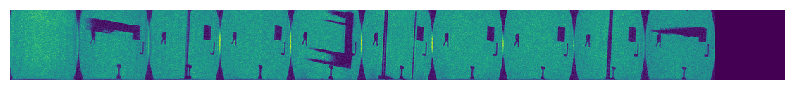

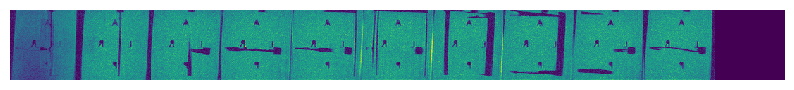

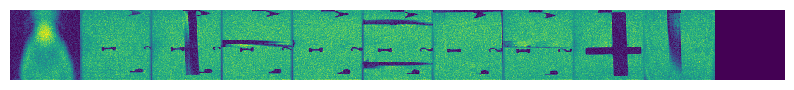

In [38]:
for mode in ["axial", "coronal", "sagittal"]: 
    tools.plot_slices(A1, mode, 10, decimate=1); 

(100, 100, 100)


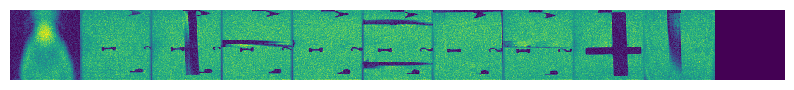

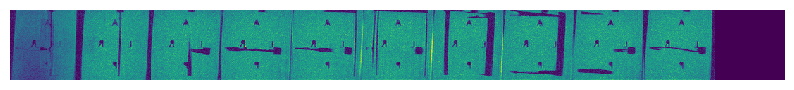

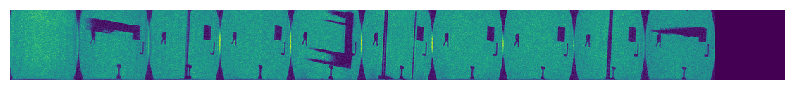

In [9]:
A1r = A1[:, :, :]
print(A1r.shape)
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A1r, mode, 10, decimate=1); 

In [10]:
print(aff1)

[[ -0.50000000   0.00000000   0.00000000  21.00000000]
 [  0.00000000  -0.25000000   0.00000000   9.50000000]
 [  0.00000000   0.00000000   0.50000000 -24.75000000]
 [  0.00000000   0.00000000   0.00000000   1.00000000]]


In [11]:
tools.ext.np.sum(aff1 ** 2, 0) ** 0.5

array([ 0.50000000,  0.25000000,  0.50000000, 33.83507795])

In [12]:
t1 = time.time()
(A2, aff2) = tools.compute_subresolution_A1_aligned(
    # A1, (0.391, 0.391, 0.391), (2.5, 2.5, 2.5), nrand=1000)
    A1r, (0.5, 0.25, 0.5), (1.25, 1.25, 1.25), nrand=1000)
t2 = time.time()
print(t2 - t1)

18.20801544189453


In [13]:
A2.shape

(41, 21, 41)

In [14]:
A2b = tools.ext.np.zeros((41, 41, 41))
A2b[:, 10:31, :] = A2
A2 = A2b

In [15]:
(A0, aff0) = tools.load_template("../templates/template-phantom-mri_resolution-1250.nii.gz")

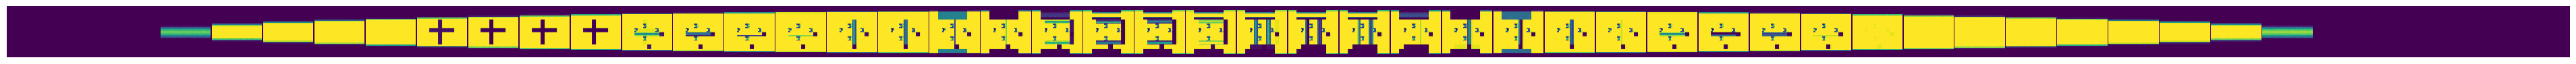

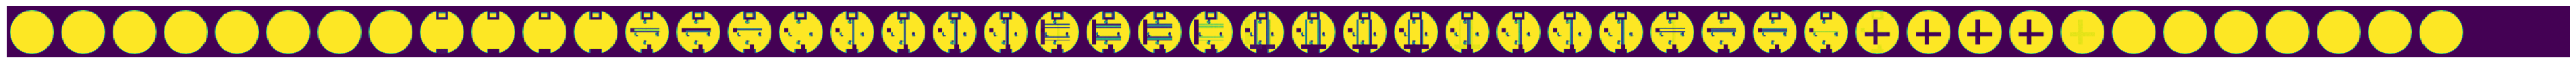

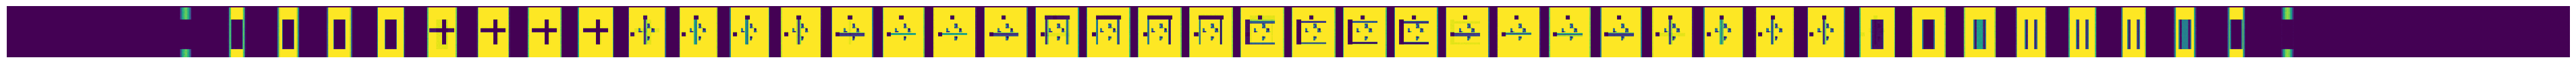

In [16]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0, mode); 

In [17]:
A0.shape

(49, 49, 49)

In [18]:
A0r = A0[9:-9, 9:-9, 9:-9]
print(A0r.shape)
patterns = tools.compute_patterns(A0r)

(31, 31, 31)


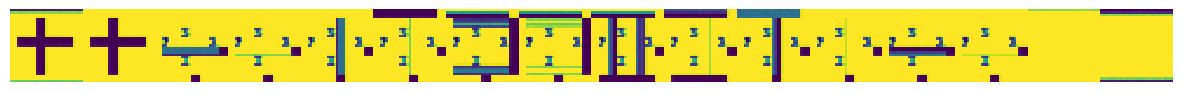

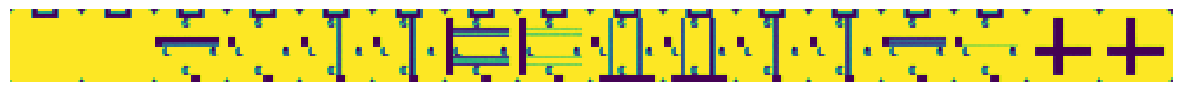

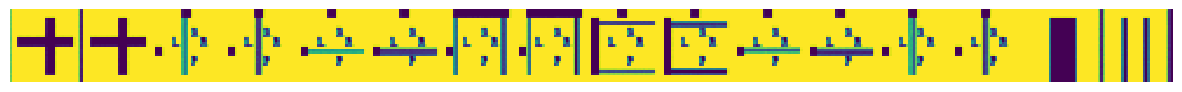

In [19]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A0r, mode, step=2); 

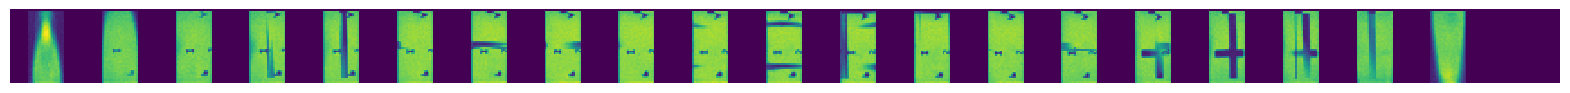

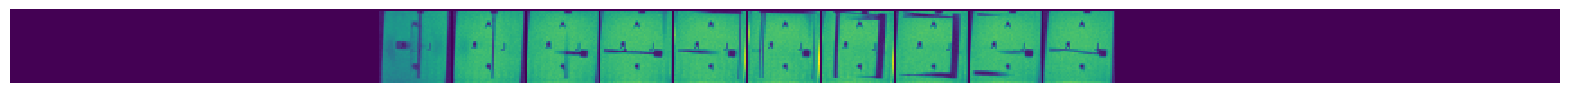

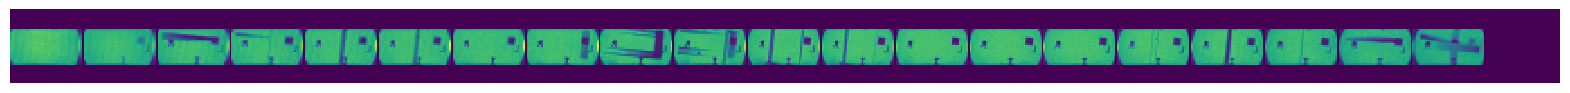

In [20]:
for mode in ["sagittal", "coronal", "axial"]: 
    tools.plot_slices(A2, mode, decimate=1, step=2); 

In [21]:
res = {}
t1 = time.time()
for k in patterns: 
    Ak = patterns[k]
    ck = tools.compute_A_inside_B_best_translation(Ak, A2)
    res[k] = {"i": ck[0], "j": ck[1], "k": ck[2], "c": ck[3]}
t2 = time.time()
print(t2 - t1)
df1 = tools.ext.pd.DataFrame(res)
df2 = df1.T
df3 = df2.sort_values(by="c")

40.4929838180542


In [22]:
df3

,i,j,k,c
"False_True_False_(1, 0, 2)",0.0,0.0,5.0,0.710878
"False_False_True_(1, 0, 2)",1.0,0.0,0.0,0.711605
"False_False_False_(2, 0, 1)",2.0,0.0,7.0,0.711636
"False_True_True_(1, 0, 2)",0.0,0.0,6.0,0.711859
"False_True_False_(2, 0, 1)",1.0,0.0,6.0,0.712113
"False_False_False_(1, 0, 2)",1.0,0.0,5.0,0.712349
"False_False_True_(2, 0, 1)",1.0,0.0,0.0,0.715543
"False_True_True_(2, 0, 1)",1.0,0.0,6.0,0.716690
"True_True_False_(1, 0, 2)",0.0,10.0,4.0,0.718130
"True_True_True_(1, 0, 2)",0.0,10.0,1.0,0.719085


In [23]:
print(aff1)

[[ -0.50000000   0.00000000   0.00000000  21.00000000]
 [  0.00000000  -0.25000000   0.00000000   9.50000000]
 [  0.00000000   0.00000000   0.50000000 -24.75000000]
 [  0.00000000   0.00000000   0.00000000   1.00000000]]


In [24]:
(flips1, orientations1) = tools.compute_flips_permutations(aff1)
print(flips1, orientations1)

[True, True, False] [np.int64(0), np.int64(1), np.int64(2)]


In [25]:
(flips2, orientations2) = ([True, False, False], [0, 2, 1])

In [26]:
tools.test_flips_orientations(flips1, flips2, orientations1, orientations2)

'.F..FF'

In [27]:
aff1r = tools.compute_transformed_affine(aff1, flips2, orientations2) 

In [28]:
print(aff1r)

[[ -0.50000000   0.00000000   0.00000000  21.00000000]
 [  0.00000000   0.00000000   0.50000000 -24.75000000]
 [  0.00000000   0.25000000   0.00000000  -9.50000000]
 [  0.00000000   0.00000000   0.00000000   1.00000000]]


In [29]:
vol2 = tools.ext.nib.Nifti1Image(A1, aff1r)

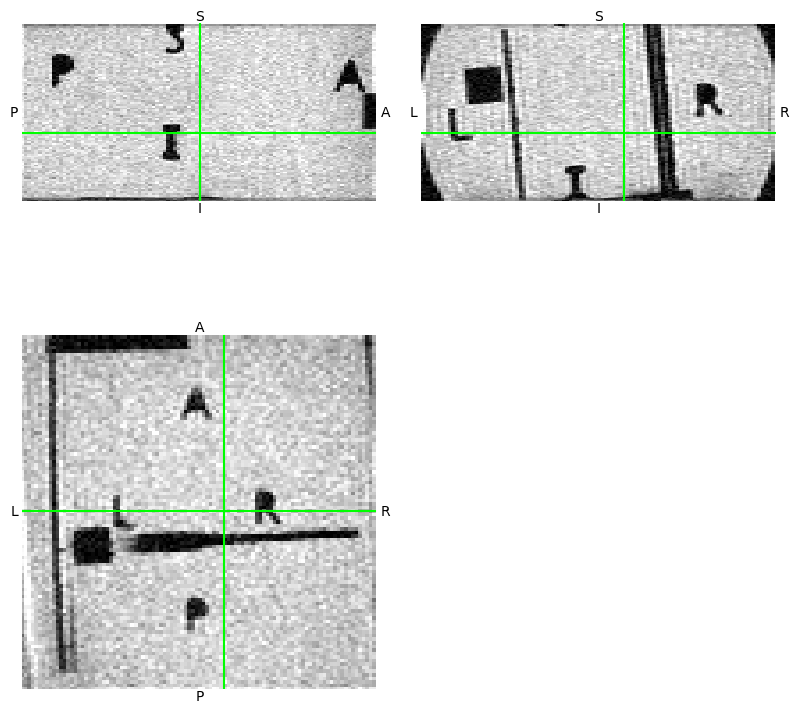

In [30]:
ov1 = vol2.orthoview()